Test Summary:      | Pass  Total  Time
JSE HL Performance |    4      4  0.6s
simulations with (n=40, p=500, 100 trials)...
=== Mean Performance Metrics (100 trials) ===
Angular Distance (radians, smaller is better):
  Raw: 0.5072
  PCA: 0.5072
  JSE: 0.3579
  Improvement: 0.1493

Optimization Bias (smaller is better):
  Raw: 0.7138
  PCA: 0.7138
  JSE: 0.5002
  Raw-JSE Improvement: 0.2136
  PCA-JSE Improvement: 0.2136

Variance Forecast Ratio (closer to 1 is better):
  Raw: 0.1584
  PCA: 0.1584
  JSE: 0.8635

Tracking Error (smaller is better):
  Raw: 0.0921
  PCA: 0.0921
  JSE: 0.0583


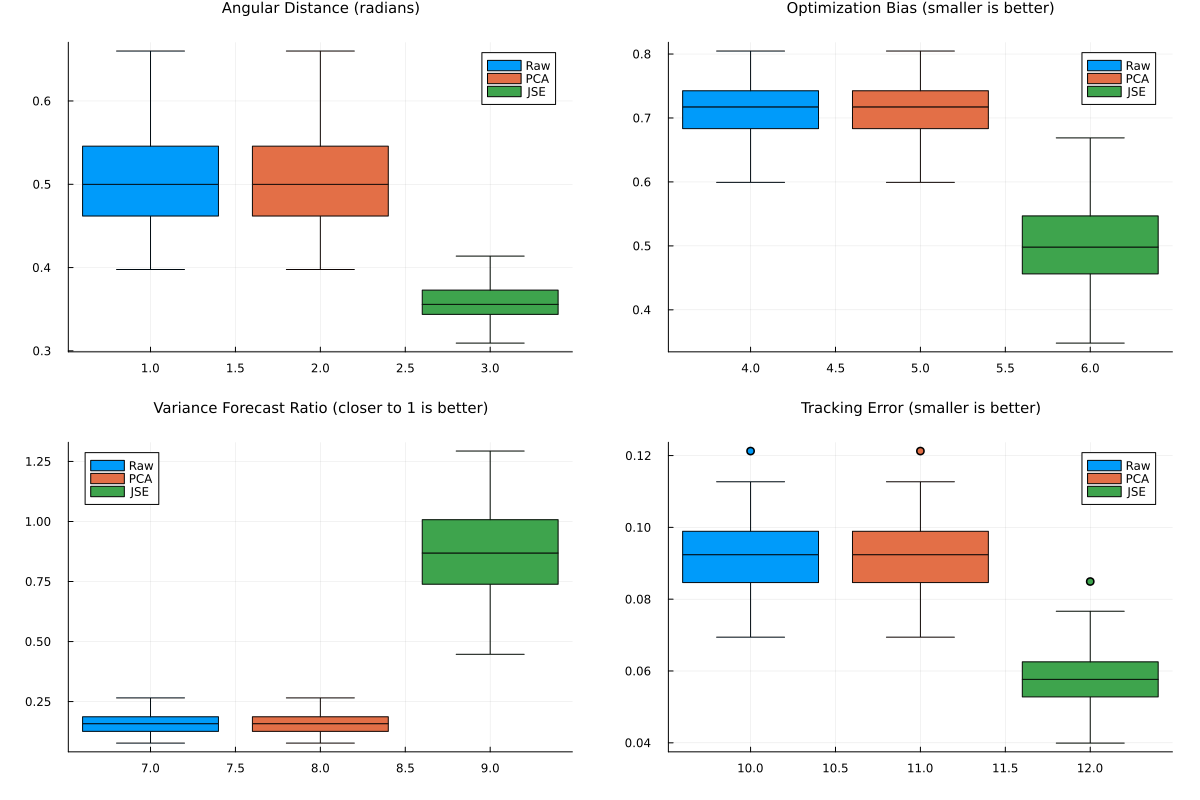

Benchmarking jse_estimator with Symmetric matrix:
  36.471 ms (41 allocations: 5.93 MiB)

Benchmarking jse_estimator without Symmetric matrix:
  36.682 ms (41 allocations: 5.93 MiB)

Benchmarking factor_cov_matrix with raw method:
  37.690 ms (23 allocations: 11.63 MiB)

Benchmarking factor_cov_matrix with jse method:
  74.267 ms (64 allocations: 17.55 MiB)


500×500 Matrix{Float64}:
 0.397075   0.0127939   0.0377634  …  0.0428592  0.0324763   0.0330304
 0.0127939  0.35467     0.0105107     0.0119291  0.00903917  0.0091934
 0.0377634  0.0105107   0.382133      0.0352106  0.0266806   0.0271358
 0.0273449  0.00761093  0.0224649     0.0254964  0.0193197   0.0196494
 0.0207443  0.0057738   0.0170423     0.019342   0.0146563   0.0149064
 0.0247261  0.00688204  0.0203135  …  0.0230546  0.0174695   0.0177675
 0.0337886  0.00940442  0.0277587     0.0315045  0.0238723   0.0242797
 0.0309798  0.00862266  0.0254512     0.0288856  0.0218879   0.0222614
 0.0443263  0.0123374   0.0364159     0.0413299  0.0313174   0.0318518
 0.0465322  0.0129514   0.0382281     0.0433866  0.032876    0.0334369
 0.0310819  0.00865108  0.0255351  …  0.0289808  0.02196     0.0223347
 0.0332168  0.00924528  0.027289      0.0309714  0.0234684   0.0238688
 0.0244057  0.00679289  0.0200503     0.0227559  0.0172432   0.0175374
 ⋮                                 ⋱                

In [12]:
using LinearAlgebra
using Statistics
using Distributions
using Test
using Plots
using Random
using Measures
using BenchmarkTools

"""
Computes the James-Stein Eigenvector (JSE) estimator for the leading eigenvector
of a factor-based covariance matrix estimated from the high-dimensional limit regime.

Params:
* S: sample covariance matrix
* n: num of obs used to compute S
* use_symmetric: Symmetric wrapper for better performance

Return:
* normalized JSE estimator of the leading eigenvector
"""
function jse_estimator(S::Matrix{T}, n::Int; use_symmetric=true) where T <: AbstractFloat
    p = size(S, 1)
    
    F = use_symmetric ? eigen(Symmetric(S)) : eigen(S)
    
    #Note to self: largest eigenvalue is last in Julia
    λ² = F.values[end]
    h = F.vectors[:, end]
    
    if sum(h) < 0
        h = -h
    end
    
    # Eq 9
    ν² = (tr(S) - λ²) / (p * (n - 1))
    
    # Eq 8
    λ = sqrt(λ²)
    m_h = mean(h)
    s² = sum((λ*h .- λ*m_h).^2)/p
    
    eps_threshold = eps(T) * λ²
    if s² <= eps_threshold
        return h ./ norm(h)  # 0 shrinkage needed
    end
    
    # Eq 7
    c_JSE = clamp(1 - ν²/s², zero(T), one(T))
    
    # Eq 6
    h_JSE = m_h .+ c_JSE.*(h .- m_h)
    return h_JSE ./ norm(h_JSE)
end

"""
Factor based covariance matrix estimator using either raw or JSE eigenvector (Eq 37)

Params:
* S: sample covariance matrix
* n: num of obs used to compute S
* method: :raw, :jse, or :pca for different eigenvector estimators

Return:
- estimated covariance matrix
"""
function factor_cov_matrix(S::Matrix{T}, n::Int; method=:jse) where T <: AbstractFloat
    p = size(S, 1)
    F = eigen(Symmetric(S))
    λ² = F.values[end]
    h = F.vectors[:, end]
    
    # Eq. 31
    ℓ² = (tr(S) - λ²) / (n - 1)
    
    if method == :raw
        b = h
    elseif method == :jse
        b = jse_estimator(S, n)
    elseif method == :pca
        # modified PCA: correct eigenvalue but keep sample eigenvector
        b = h
    else
        error("Unknown method: $method")
    end
    
    # factor covariance matrix Eq. 37
    Σ_hat = (λ² - ℓ²) * (b * b') + (n/p) * ℓ² * I
    
    return Σ_hat
end

"""
Simulate data from a one factor model where β ~ N(1, 0.25)
factor returns with σ=0.16, specific returns with δ=0.60

Params:
* n: Num of obs
* p: Numb of vars
* σ: SD of factor returns (default: 0.16)
* δ: SD of specific returns (default: 0.60)
* mean_beta: mean of the beta distribution (default: 1.0)
* var_beta: var of the beta distribution (default: 0.25)

Return:
* X:  synthetic p x n data matrix
* β: true factor loadings
* Σ: true covariance matrix
"""
function simulate_factor_data(n::Int, p::Int; σ=0.16, δ=0.60, mean_beta=1.0, var_beta=0.25, seed=nothing)
    if seed !== nothing
        Random.seed!(seed)
    end
    
    β = rand(Normal(mean_beta, sqrt(var_beta)), p)
    
    # (common factor f)
    f = rand(Normal(0, σ), n)
    
    # specific returns (with t-distribution with 5)
    ϵ = rand(TDist(5), (p, n)) .* (δ / sqrt(5/(5-2)))
    
    X = β * f' + ϵ
    
    # Eq. 11
    Σ = (σ^2) * (β * β') + (δ^2) * I
    
    return X, β, Σ
end

"""
Computes the minimum variance portfolio weights.

Param:
* Σ: The covariance matrix

Return:
* vector of portfolio weights that minimize variance
"""
function min_variance_portfolio(Σ::Matrix{T}) where T <: AbstractFloat
    p = size(Σ, 1)
    ones_vec = ones(p)
    
    # Eq. 25
    # subject to w'1 = 1
    Σ_inv = inv(Σ)
    w = (Σ_inv * ones_vec) ./ (ones_vec' * Σ_inv * ones_vec)
    
    return w
end

"""
The angular distance (smallest angle) between two vectors

Params:
* v1, v2: The vectors to compare

Return:
* The angle between the vectors in radians
"""
function angular_distance(v1::Vector{T}, v2::Vector{T}) where T <: AbstractFloat
    v1_norm = v1 ./ norm(v1)
    v2_norm = v2 ./ norm(v2)
    
    if sum(v1_norm) < 0
        v1_norm = -v1_norm
    end
    if sum(v2_norm) < 0
        v2_norm = -v2_norm
    end
    
    cos_sim = clamp(dot(v1_norm, v2_norm), -1.0, 1.0)
    
    return acos(cos_sim)
end

"""
Compute the optimization bias metric, which measures how far the estimated 
portfolio weights are from the true optimal weights.

Params:
* w_est: The estimated portfolio weights
* w_true: The true optimal portfolio weights
* Σ: The true covariance matrix

Return:
* The optimization bias metric
"""
function optimization_bias(w_est::Vector{T}, w_true::Vector{T}, Σ::Matrix{T}) where T <: AbstractFloat
    # Eq. 27
    tvr = (w_true' * Σ * w_true) / (w_est' * Σ * w_est)
    
    # 1 - TVR so that smaller is better 
    return 1.0 - tvr
end

"""
Compute the variance forecast ratio which measures the accuracy of the variance forecast

Params:
* w: portfolio weights
* Σ_est: estimated covariance matrix
* Σ_true: true covariance matrix

Return:
* variance forecast ratio (1.0 is perfect, closer the better)
"""
function variance_forecast_ratio(w::Vector{T}, Σ_est::Matrix{T}, Σ_true::Matrix{T}) where T <: AbstractFloat
    # Eq. 26
    vfr = (w' * Σ_est * w) / (w' * Σ_true * w)
    
    return vfr
end

"""
Tracking error between the estimated and true optimal portfolios.

Params:
* w_est: estimated portfolio weights
* w_true: true optimal portfolio weights
* Σ: true covariance matrix

Return:
* The tracking error
"""
function tracking_error(w_est::Vector{T}, w_true::Vector{T}, Σ::Matrix{T}) where T <: AbstractFloat
    # Eq. 28
    te_squared = (w_est - w_true)' * Σ * (w_est - w_true)
    
    return sqrt(te_squared)
end

"""
HL trials to compare different estimators.

Params:
* n: num of obs
* p: num of vars
* num_trials: num of sim trials
* kwargs: params passed to simulate_factor_data

Return:
* A dict with preformance metrics
"""
function run_hl_trials(n=40, p=500, num_trials=100; kwargs...)
    metrics = Dict(
        :angular => Dict(:raw => Float64[], :pca => Float64[], :jse => Float64[]),
        :optim_bias => Dict(:raw => Float64[], :pca => Float64[], :jse => Float64[]),
        :vfr => Dict(:raw => Float64[], :pca => Float64[], :jse => Float64[]),
        :tracking_error => Dict(:raw => Float64[], :pca => Float64[], :jse => Float64[])
    )
    
    for trial in 1:num_trials
        X, β, Σ = simulate_factor_data(n, p, seed=trial; kwargs...)
        S = cov(X, dims=2)
        w_true = min_variance_portfolio(Σ)
        
        # Leading eigenvector from sample covariance matrix
        h_raw = eigen(Symmetric(S)).vectors[:, end]
        if sum(h_raw) < 0
            h_raw = -h_raw
        end
        
        h_jse = jse_estimator(S, n)
        
        # normalized true β
        β_norm = β ./ norm(β)
        if sum(β_norm) < 0
            β_norm = -β_norm
        end
        
        push!(metrics[:angular][:raw], angular_distance(h_raw, β_norm))
        push!(metrics[:angular][:pca], angular_distance(h_raw, β_norm))
        push!(metrics[:angular][:jse], angular_distance(h_jse, β_norm))
        
        for method in [:raw, :pca, :jse]
            Σ_est = factor_cov_matrix(S, n, method=method)
            w_est = min_variance_portfolio(Σ_est)
            
            push!(metrics[:optim_bias][method], optimization_bias(w_est, w_true, Σ))
            push!(metrics[:vfr][method], variance_forecast_ratio(w_est, Σ_est, Σ))
            push!(metrics[:tracking_error][method], tracking_error(w_est, w_true, Σ))
        end
    end
    
    return metrics
end

"""
Plots comparing the performance of different estimators for a given metric.

Params:
* metrics: The metrics dict from run_hl_trials
* metric_key: The key of the metric to plot
* title: you know what
"""
function plot_metrics(metrics::Dict, metric_key::Symbol, title::String="")
    boxplot(
        [metrics[metric_key][:raw], metrics[metric_key][:pca], metrics[metric_key][:jse]],
        labels=["Raw" "PCA" "JSE"],
        title=isempty(title) ? string(metric_key) : title,
        ylabel=string(metric_key),
        yformatter = :auto
    )
end

"""
Plots
Params:
* metrics: The metrics dict from run_hl_trials

Return:
* A plot object
"""
function plot_hl_results(metrics::Dict)
    p = plot(layout=(2,2), size=(1200, 800), margin=5mm)
    
    subplot_titles = [
        "Angular Distance (radians)", 
        "Optimization Bias (smaller is better)",
        "Variance Forecast Ratio (closer to 1 is better)",
        "Tracking Error (smaller is better)"
    ]
    
    metric_keys = [:angular, :optim_bias, :vfr, :tracking_error]
    
    for (i, (key, title)) in enumerate(zip(metric_keys, subplot_titles))
        if haskey(metrics, key) && 
           all(haskey(metrics[key], method) && !isempty(metrics[key][method]) 
               for method in [:raw, :pca, :jse])
            
            boxplot!(
                p[i],
                [metrics[key][:raw], metrics[key][:pca], metrics[key][:jse]],
                labels=["Raw" "PCA" "JSE"],
                title=title,
                titlefontsize=10,
                xtickfontsize=8,
                ytickfontsize=8,
                yformatter=:auto
            )
        else
            annotate!(p[i], 0.5, 0.5, text("No data available for $(key)", 10))
        end
    end
    
    return p
end

"""
Benchmark different implementations of JSE estimator.

Params:
* n: num of obs
* p: num of vars
"""
function benchmark_implementations(n::Int, p::Int)
    X, β, Σ = simulate_factor_data(n, p)
    S = cov(X, dims=2)
    
    println("Benchmarking jse_estimator with Symmetric matrix:")
    @btime jse_estimator($S, $n, use_symmetric=true)
    
    println("\nBenchmarking jse_estimator without Symmetric matrix:")
    @btime jse_estimator($S, $n, use_symmetric=false)
    
    println("\nBenchmarking factor_cov_matrix with raw method:")
    @btime factor_cov_matrix($S, $n, method=:raw)
    
    println("\nBenchmarking factor_cov_matrix with jse method:")
    @btime factor_cov_matrix($S, $n, method=:jse)
end

function run_hl_trials_verbose(n=40, p=500, num_trials=5; kwargs...)
    metrics = run_hl_trials(n, p, num_trials; kwargs...)
    
    println("=== Mean Performance Metrics ($num_trials trials) ===")
    println("Angular Distance (radians, smaller is better):")
    println("  Raw: $(round(mean(metrics[:angular][:raw]), digits=4))")
    println("  PCA: $(round(mean(metrics[:angular][:pca]), digits=4))")
    println("  JSE: $(round(mean(metrics[:angular][:jse]), digits=4))")
    println("  Improvement: $(round(mean(metrics[:angular][:raw]) - mean(metrics[:angular][:jse]), digits=4))")
    
    println("\nOptimization Bias (smaller is better):")
    println("  Raw: $(round(mean(metrics[:optim_bias][:raw]), digits=4))")
    println("  PCA: $(round(mean(metrics[:optim_bias][:pca]), digits=4))")
    println("  JSE: $(round(mean(metrics[:optim_bias][:jse]), digits=4))")
    println("  Raw-JSE Improvement: $(round(mean(metrics[:optim_bias][:raw]) - mean(metrics[:optim_bias][:jse]), digits=4))")
    println("  PCA-JSE Improvement: $(round(mean(metrics[:optim_bias][:pca]) - mean(metrics[:optim_bias][:jse]), digits=4))")
    
    println("\nVariance Forecast Ratio (closer to 1 is better):")
    println("  Raw: $(round(mean(metrics[:vfr][:raw]), digits=4))")
    println("  PCA: $(round(mean(metrics[:vfr][:pca]), digits=4))")
    println("  JSE: $(round(mean(metrics[:vfr][:jse]), digits=4))")
    
    println("\nTracking Error (smaller is better):")
    println("  Raw: $(round(mean(metrics[:tracking_error][:raw]), digits=4))")
    println("  PCA: $(round(mean(metrics[:tracking_error][:pca]), digits=4))")
    println("  JSE: $(round(mean(metrics[:tracking_error][:jse]), digits=4))")
    
    return metrics
end

@testset "JSE HL Performance" begin
    # small test
    metrics = run_hl_trials(40, 100, 10)
    
    # angular improvement
    @test mean(metrics[:angular][:jse]) < mean(metrics[:angular][:raw])
    
    # optimization bias with tolerance
    @test mean(metrics[:optim_bias][:jse]) < mean(metrics[:optim_bias][:raw]) + 0.02
    
    # variance forecast ratio (should be closer to 1.0)
    avg_raw = mean(metrics[:vfr][:raw])
    avg_jse = mean(metrics[:vfr][:jse])
    
    # distance from 1.0
    dist_raw = abs(avg_raw - 1.0)
    dist_jse = abs(avg_jse - 1.0)
    
    @test dist_jse < dist_raw
    
    # tracking error should be smaller for JSE
    @test mean(metrics[:tracking_error][:jse]) < mean(metrics[:tracking_error][:raw])
end

function run_paper_simulation(plot_results=true; n=40, p=500, trials=100)
    println("simulations with (n=$n, p=$p, $trials trials)...")
    metrics = run_hl_trials_verbose(n, p, trials, σ=0.16, δ=0.60, mean_beta=1.0, var_beta=0.25)
    
    if plot_results
        plt = plot_hl_results(metrics)
        display(plt)
    end
    
    return metrics
end

Random.seed!(42)
metrics = run_paper_simulation(true, n=40, p=500, trials=100)

benchmark_implementations(40, 500)

In [ ]:
using LinearAlgebra
using Statistics
using Distributions
using Test
using Plots
using Random
using Measures
using BenchmarkTools

const has_cuda = try
    using CUDA
    CUDA.functional()
catch
    false
end

"""
Check if CUDA is avail

"""
function has_cuda_support()
    return has_cuda
end

"""
Computes the James-Stein Eigenvector (JSE) estimator for the leading eigenvector
of a factor-based covariance matrix estimated from the high-dimensional limit regime.

Params:
* S: sample covariance matrix
* n: num of obs used to compute S
* use_symmetric: Symmetric wrapper for better performance
* use_cuda: use GPU acceleration if available

Return:
* normalized JSE estimator of the leading eigenvector
"""
function jse_estimator(S::Matrix{T}, n::Int; use_symmetric=true, use_cuda=has_cuda) where T <: AbstractFloat
    if use_cuda && has_cuda
        return jse_estimator_cuda(S, n)
    else
        p = size(S, 1)
        
        F = use_symmetric ? eigen(Symmetric(S)) : eigen(S)
        
        #Note to self: largest eigenvalue is last in Julia
        λ² = F.values[end]
        h = F.vectors[:, end]
        
        if sum(h) < 0
            h = -h
        end
        
        # Eq 9
        ν² = (tr(S) - λ²) / (p * (n - 1))
        
        # Eq 8
        λ = sqrt(λ²)
        m_h = mean(h)
        s² = sum((λ*h .- λ*m_h).^2)/p
        
        eps_threshold = eps(T) * λ²
        if s² <= eps_threshold
            return h ./ norm(h)  # 0 shrinkage needed
        end
        
        # Eq 7
        c_JSE = clamp(1 - ν²/s², zero(T), one(T))
        
        # Eq 6
        h_JSE = m_h .+ c_JSE.*(h .- m_h)
        return h_JSE ./ norm(h_JSE)
    end
end

"""
CUDA JSE estimator

Params:
* S: sample covariance matrix 
* n: num of obs used to compute S

Return:
* normalized JSE estimator of the leading eigenvector
"""
function jse_estimator_cuda(S::Matrix{T}, n::Int) where T <: AbstractFloat
    if !has_cuda
        error("CUDA not available, use CPU implementation instead")
    end
    
    p = size(S, 1)
    
    # move to GPU
    d_S = CuMatrix(Symmetric(S))
    
    #  eigendecomposition on GPU
    F = CUDA.CUSOLVER.syevd!('V', 'U', d_S)
    
    λ² = Array(F.values[end])
    h = Array(F.vectors[:, end])
    
    if sum(h) < 0
        h = -h
    end
    
    # Eq 9
    ν² = (tr(S) - λ²) / (p * (n - 1))
    
    # Eq 8
    λ = sqrt(λ²)
    m_h = mean(h)
    s² = sum((λ*h .- λ*m_h).^2)/p
    
    eps_threshold = eps(T) * λ²
    if s² <= eps_threshold
        return h ./ norm(h)  # 0 shrinkage needed
    end
    
    # Eq 7
    c_JSE = clamp(1 - ν²/s², zero(T), one(T))
    
    # Eq 6
    h_JSE = m_h .+ c_JSE.*(h .- m_h)
    return h_JSE ./ norm(h_JSE)
end

"""
Factor based covariance matrix estimator using either raw or JSE eigenvector (Eq 37)

Params:
* S: sample covariance matrix
* n: num of obs used to compute S
* method: :raw, :jse, or :pca for different eigenvector estimators
* use_cuda: use GPU acceleration if available

Return:
* estimated covariance matrix
"""
function factor_cov_matrix(S::Matrix{T}, n::Int; method=:jse, use_cuda=has_cuda) where T <: AbstractFloat
    if use_cuda && has_cuda
        return factor_cov_matrix_cuda(S, n, method=method)
    else
        p = size(S, 1)
        F = eigen(Symmetric(S))
        λ² = F.values[end]
        h = F.vectors[:, end]
        
        # Eq. 31
        ℓ² = (tr(S) - λ²) / (n - 1)
        
        if method == :raw
            b = h
        elseif method == :jse
            b = jse_estimator(S, n, use_cuda=false)
        elseif method == :pca
            # modified PCA: correct eigenvalue but keep sample eigenvector
            b = h
        else
            error("Unknown method: $method")
        end
        
        # factor covariance matrix Eq. 37
        Σ_hat = (λ² - ℓ²) * (b * b') + (n/p) * ℓ² * I
        
        return Σ_hat
    end
end

"""
CUDA factor_cov_matrix

Params:
* S: sample covariance matrix
* n: num of obs used to compute S
* method: :raw, :jse, or :pca for different eigenvector estimators

Return:
* estimated covariance matrix
"""
function factor_cov_matrix_cuda(S::Matrix{T}, n::Int; method=:jse) where T <: AbstractFloat
    if !has_cuda
        error("CUDA not avail, using CPU instead")
    end
    
    p = size(S, 1)
    
    d_S = CuMatrix(Symmetric(S))
    
    F = CUDA.CUSOLVER.syevd!('V', 'U', d_S)
    
    #move back to cpu
    λ² = Array(F.values[end])
    h = Array(F.vectors[:, end])
    
    # Eq. 31
    ℓ² = (tr(S) - λ²) / (n - 1)
    
    if method == :raw
        b = h
    elseif method == :jse
        b = jse_estimator_cuda(S, n)
    elseif method == :pca
        b = h
    else
        error("Unknown method: $method")
    end
    
    # b to GPU
    d_b = CuVector(b)
    
    d_bb_t = d_b * d_b'
    d_Σ_hat = (λ² - ℓ²) * d_bb_t + (n/p) * ℓ² * CUDA.I(p)
    
    return Array(d_Σ_hat)
end

"""
Simulate data from a one factor model where β ~ N(1, 0.25)
factor returns with σ=0.16, specific returns with δ=0.60

Params:
* n: Num of obs
* p: Numb of vars
* σ: SD of factor returns (default: 0.16)
* δ: SD of specific returns (default: 0.60)
* mean_beta: mean of the beta distribution (default: 1.0)
* var_beta: var of the beta distribution (default: 0.25)

Return:
* X:  synthetic p x n data matrix
* β: true factor loadings
* Σ: true covariance matrix
"""
function simulate_factor_data(n::Int, p::Int; σ=0.16, δ=0.60, mean_beta=1.0, var_beta=0.25, seed=nothing)
    if seed !== nothing
        Random.seed!(seed)
    end
    
    β = rand(Normal(mean_beta, sqrt(var_beta)), p)
    
    # (common factor f)
    f = rand(Normal(0, σ), n)
    
    # specific returns (with t-distribution with 5)
    ϵ = rand(TDist(5), (p, n)) .* (δ / sqrt(5/(5-2)))
    
    X = β * f' + ϵ
    
    # Eq. 11
    Σ = (σ^2) * (β * β') + (δ^2) * I
    
    return X, β, Σ
end

"""
Computes the minimum variance portfolio weights.

Param:
* Σ: The covariance matrix
* use_cuda: if gpu 

Return:
* vector of portfolio weights that minimize variance
"""
function min_variance_portfolio(Σ::Matrix{T}; use_cuda=has_cuda) where T <: AbstractFloat
    if use_cuda && has_cuda
        return min_variance_portfolio_cuda(Σ)
    else
        p = size(Σ, 1)
        ones_vec = ones(p)
        
        # Eq. 25
        # subject to w'1 = 1
        Σ_inv = inv(Σ)
        w = (Σ_inv * ones_vec) ./ (ones_vec' * Σ_inv * ones_vec)
        
        return w
    end
end

"""
CUDA min_variance_portfolio

Params:
* Σ: The covariance matrix

Return:
* vector of portfolio weights that minimize variance
"""
function min_variance_portfolio_cuda(Σ::Matrix{T}) where T <: AbstractFloat
    if !has_cuda
        error("CUDA not avail, using CPU instead")
    end
    
    p = size(Σ, 1)
    
    d_Σ = CuMatrix(Σ)
    d_ones = CUDA.ones(p)
    
    # inverse on GPU
    d_Σ_inv = CUDA.inv(d_Σ)
    
    d_numerator = d_Σ_inv * d_ones
    denominator = (d_ones' * d_numerator)[1]  # Scalar result
    d_w = d_numerator ./ denominator
    
    return Array(d_w)
end

"""
The angular distance (smallest angle) between two vectors

Params:
* v1, v2: The vectors to compare

Return:
* The angle between the vectors in radians
"""
function angular_distance(v1::Vector{T}, v2::Vector{T}) where T <: AbstractFloat
    v1_norm = v1 ./ norm(v1)
    v2_norm = v2 ./ norm(v2)
    
    if sum(v1_norm) < 0
        v1_norm = -v1_norm
    end
    if sum(v2_norm) < 0
        v2_norm = -v2_norm
    end
    
    cos_sim = clamp(dot(v1_norm, v2_norm), -1.0, 1.0)
    
    return acos(cos_sim)
end

"""
Compute the optimization bias metric, which measures how far the estimated 
portfolio weights are from the true optimal weights.

Params:
* w_est: The estimated portfolio weights
* w_true: The true optimal portfolio weights
* Σ: The true covariance matrix

Return:
* The optimization bias metric
"""
function optimization_bias(w_est::Vector{T}, w_true::Vector{T}, Σ::Matrix{T}) where T <: AbstractFloat
    # Eq. 27
    tvr = (w_true' * Σ * w_true) / (w_est' * Σ * w_est)
    
    return 1.0 - tvr
end

"""
Compute the variance forecast ratio which measures the accuracy of the variance forecast

Params:
* w: portfolio weights
* Σ_est: estimated covariance matrix
* Σ_true: true covariance matrix

Return:
* variance forecast ratio (1.0 is perfect, closer the better)
"""
function variance_forecast_ratio(w::Vector{T}, Σ_est::Matrix{T}, Σ_true::Matrix{T}) where T <: AbstractFloat
    # Eq. 26
    vfr = (w' * Σ_est * w) / (w' * Σ_true * w)
    
    return vfr
end

"""
Tracking error between the estimated and true optimal portfolios.

Params:
* w_est: estimated portfolio weights
* w_true: true optimal portfolio weights
* Σ: true covariance matrix

Return:
* The tracking error
"""
function tracking_error(w_est::Vector{T}, w_true::Vector{T}, Σ::Matrix{T}) where T <: AbstractFloat
    # Eq. 28
    te_squared = (w_est - w_true)' * Σ * (w_est - w_true)
    
    return sqrt(te_squared)
end

"""
HL trials to compare different estimators.

Params:
* n: num of obs
* p: num of vars
* num_trials: num of sim trials
* use_cuda: use GPU acceleration if available
* kwargs: params passed to simulate_factor_data

Return:
* A dict with preformance metrics
"""
function run_hl_trials(n=40, p=500, num_trials=100; use_cuda=has_cuda, kwargs...)
    metrics = Dict(
        :angular => Dict(:raw => Float64[], :pca => Float64[], :jse => Float64[]),
        :optim_bias => Dict(:raw => Float64[], :pca => Float64[], :jse => Float64[]),
        :vfr => Dict(:raw => Float64[], :pca => Float64[], :jse => Float64[]),
        :tracking_error => Dict(:raw => Float64[], :pca => Float64[], :jse => Float64[])
    )
    
    for trial in 1:num_trials
        X, β, Σ = simulate_factor_data(n, p, seed=trial; kwargs...)
        S = cov(X, dims=2)
        w_true = min_variance_portfolio(Σ, use_cuda=use_cuda)
        
        if use_cuda && has_cuda
            d_S = CuMatrix(Symmetric(S))
            F = CUDA.CUSOLVER.syevd!('V', 'U', d_S)
            h_raw = Array(F.vectors[:, end])
        else
            h_raw = eigen(Symmetric(S)).vectors[:, end]
        end
        
        if sum(h_raw) < 0
            h_raw = -h_raw
        end
        
        h_jse = jse_estimator(S, n, use_cuda=use_cuda)
        
        β_norm = β ./ norm(β)
        if sum(β_norm) < 0
            β_norm = -β_norm
        end
        
        push!(metrics[:angular][:raw], angular_distance(h_raw, β_norm))
        push!(metrics[:angular][:pca], angular_distance(h_raw, β_norm))
        push!(metrics[:angular][:jse], angular_distance(h_jse, β_norm))
        
        for method in [:raw, :pca, :jse]
            Σ_est = factor_cov_matrix(S, n, method=method, use_cuda=use_cuda)
            w_est = min_variance_portfolio(Σ_est, use_cuda=use_cuda)
            
            push!(metrics[:optim_bias][method], optimization_bias(w_est, w_true, Σ))
            push!(metrics[:vfr][method], variance_forecast_ratio(w_est, Σ_est, Σ))
            push!(metrics[:tracking_error][method], tracking_error(w_est, w_true, Σ))
        end
    end
    
    return metrics
end

"""
Plots comparing the performance of different estimators for a given metric.

Params:
* metrics: The metrics dict from run_hl_trials
* metric_key: The key of the metric to plot
* title: you know what
"""
function plot_metrics(metrics::Dict, metric_key::Symbol, title::String="")
    boxplot(
        [metrics[metric_key][:raw], metrics[metric_key][:pca], metrics[metric_key][:jse]],
        labels=["Raw" "PCA" "JSE"],
        title=isempty(title) ? string(metric_key) : title,
        ylabel=string(metric_key),
        yformatter = :auto
    )
end

"""
Plots
Params:
* metrics: The metrics dict from run_hl_trials

Return:
* A plot object
"""
function plot_hl_results(metrics::Dict)
    p = plot(layout=(2,2), size=(1200, 800), margin=5mm)
    
    subplot_titles = [
        "Angular Distance (radians)", 
        "Optimization Bias (smaller is better)",
        "Variance Forecast Ratio (closer to 1 is better)",
        "Tracking Error (smaller is better)"
    ]
    
    metric_keys = [:angular, :optim_bias, :vfr, :tracking_error]
    
    for (i, (key, title)) in enumerate(zip(metric_keys, subplot_titles))
        if haskey(metrics, key) && 
           all(haskey(metrics[key], method) && !isempty(metrics[key][method]) 
               for method in [:raw, :pca, :jse])
            
            boxplot!(
                p[i],
                [metrics[key][:raw], metrics[key][:pca], metrics[key][:jse]],
                labels=["Raw" "PCA" "JSE"],
                title=title,
                titlefontsize=10,
                xtickfontsize=8,
                ytickfontsize=8,
                yformatter=:auto
            )
        else
            annotate!(p[i], 0.5, 0.5, text("No data available for $(key)", 10))
        end
    end
    
    return p
end

"""
Benchmark different implementations of JSE estimator.

Params:
* n: num of obs
* p: num of vars
* compare_cuda: benchmark CUDA versions or not
"""
function benchmark_implementations(n::Int, p::Int; compare_cuda=has_cuda)
    X, β, Σ = simulate_factor_data(n, p)
    S = cov(X, dims=2)
    
    println("Benchmarking CPU implementations:")
    println("JSE estimator with Symmetric matrix:")
    @btime jse_estimator($S, $n, use_symmetric=true, use_cuda=false)
    
    println("\nJSE estimator without Symmetric matrix:")
    @btime jse_estimator($S, $n, use_symmetric=false, use_cuda=false)
    
    println("\nFactor covariance matrix with raw method:")
    @btime factor_cov_matrix($S, $n, method=:raw, use_cuda=false)
    
    println("\nFactor covariance matrix with JSE method:")
    @btime factor_cov_matrix($S, $n, method=:jse, use_cuda=false)
    
    println("\nMinimum variance portfolio:")
    @btime min_variance_portfolio($Σ, use_cuda=false)
    
    if compare_cuda && has_cuda
        println("\n\nBenchmarking CUDA implementations:")
        println("JSE estimator with CUDA:")
        @btime jse_estimator($S, $n, use_cuda=true)
        
        println("\nFactor covariance matrix with raw method (CUDA):")
        @btime factor_cov_matrix($S, $n, method=:raw, use_cuda=true)
        
        println("\nFactor covariance matrix with JSE method (CUDA):")
        @btime factor_cov_matrix($S, $n, method=:jse, use_cuda=true)
        
        println("\nMinimum variance portfolio (CUDA):")
        @btime min_variance_portfolio($Σ, use_cuda=true)
    elseif compare_cuda
        println("\nCUDA benchmarks skipped: CUDA not available")
    end
end

function run_hl_trials_verbose(n=40, p=500, num_trials=5; use_cuda=has_cuda, kwargs...)
    if use_cuda && has_cuda
        println("Running with CUDA")
    else
        println("Running with CPU")
    end
    
    metrics = run_hl_trials(n, p, num_trials, use_cuda=use_cuda; kwargs...)
    
    println("=== Mean Performance Metrics ($num_trials trials) ===")
    println("Angular Distance (radians, smaller is better):")
    println("  Raw: $(round(mean(metrics[:angular][:raw]), digits=4))")
    println("  PCA: $(round(mean(metrics[:angular][:pca]), digits=4))")
    println("  JSE: $(round(mean(metrics[:angular][:jse]), digits=4))")
    println("  Improvement: $(round(mean(metrics[:angular][:raw]) - mean(metrics[:angular][:jse]), digits=4))")
    
    println("\nOptimization Bias (smaller is better):")
    println("  Raw: $(round(mean(metrics[:optim_bias][:raw]), digits=4))")
    println("  PCA: $(round(mean(metrics[:optim_bias][:pca]), digits=4))")
    println("  JSE: $(round(mean(metrics[:optim_bias][:jse]), digits=4))")
    println("  Raw-JSE Improvement: $(round(mean(metrics[:optim_bias][:raw]) - mean(metrics[:optim_bias][:jse]), digits=4))")
    println("  PCA-JSE Improvement: $(round(mean(metrics[:optim_bias][:pca]) - mean(metrics[:optim_bias][:jse]), digits=4))")
    
    println("\nVariance Forecast Ratio (closer to 1 is better):")
    println("  Raw: $(round(mean(metrics[:vfr][:raw]), digits=4))")
    println("  PCA: $(round(mean(metrics[:vfr][:pca]), digits=4))")
    println("  JSE: $(round(mean(metrics[:vfr][:jse]), digits=4))")
    
    println("\nTracking Error (smaller is better):")
    println("  Raw: $(round(mean(metrics[:tracking_error][:raw]), digits=4))")
    println("  PCA: $(round(mean(metrics[:tracking_error][:pca]), digits=4))")
    println("  JSE: $(round(mean(metrics[:tracking_error][:jse]), digits=4))")
    
    return metrics
end

@testset "JSE HL Performance" begin
    # small test
    metrics = run_hl_trials(40, 100, 10, use_cuda=false)
    
    # angular improvement
    @test mean(metrics[:angular][:jse]) < mean(metrics[:angular][:raw])
    
    # optimization bias with tolerance
    @test mean(metrics[:optim_bias][:jse]) < mean(metrics[:optim_bias][:raw]) + 0.02
    
    # variance forecast ratio (should be closer to 1.0)
    avg_raw = mean(metrics[:vfr][:raw])
    avg_jse = mean(metrics[:vfr][:jse])
    
    # distance from 1.0
    dist_raw = abs(avg_raw - 1.0)
    dist_jse = abs(avg_jse - 1.0)
    
    @test dist_jse < dist_raw
    
    # tracking error should be smaller for JSE
    @test mean(metrics[:tracking_error][:jse]) < mean(metrics[:tracking_error][:raw])
end

function run_paper_simulation(plot_results=true; n=40, p=500, trials=100, use_cuda=has_cuda)
    println("simulations with (n=$n, p=$p, $trials trials)...")
    metrics = run_hl_trials_verbose(n, p, trials, use_cuda=use_cuda, σ=0.16, δ=0.60, mean_beta=1.0, var_beta=0.25)
    
    if plot_results
        plt = plot_hl_results(metrics)
        display(plt)
    end
    
    return metrics
end

"""
CPU vs GPU comparison for different problem sizes.

Params:
* sizes: array of problem dimensions to test
* trials: num of trials for each size
"""
function benchmark_cuda_vs_cpu(sizes=[100, 200, 500, 1000], trials=5)
    if !has_cuda
        println("CUDA not available, skipping comparison")
        return nothing
    end
    
    results = Dict(
        :cpu_time => Float64[],
        :gpu_time => Float64[],
        :size => Int[]
    )
    
    for p in sizes
        push!(results[:size], p)
        
        # Warmup
        run_hl_trials(40, p, 1, use_cuda=false)
        run_hl_trials(40, p, 1, use_cuda=true)
        
        # CPU timing
        cpu_start = time()
        run_hl_trials(40, p, trials, use_cuda=false)
        cpu_time = time() - cpu_start
        push!(results[:cpu_time], cpu_time)
        
        # GPU timing
        gpu_start = time()
        run_hl_trials(40, p, trials, use_cuda=true)
        gpu_time = time() - gpu_start
        push!(results[:gpu_time], gpu_time)
        
        println("Size p=$p: CPU time = $(round(cpu_time, digits=2))s, GPU time = $(round(gpu_time, digits=2))s, Speedup = $(round(cpu_time/gpu_time, digits=2))x")
    end
    
    # Create comparison plot
    p = plot(results[:size], results[:cpu_time], 
        label="CPU", marker=:circle, legend=:topleft,
        xlabel="Dimension (p)", ylabel="Runtime (seconds)",
        title="CPU vs GPU Performance Comparison ($trials trials)")
    plot!(p, results[:size], results[:gpu_time], 
        label="GPU", marker=:square)
    
    # Plot speedup on secondary axis
    speedup = results[:cpu_time] ./ results[:gpu_time]
    plot!(twinx(p), results[:size], speedup, 
        label="Speedup", color=:green, marker=:diamond,
        ylabel="Speedup (x)", legend=:topright)
    
    display(p)
    return results
end

# Main execution - use CPU by default for consistency across all systems
Random.seed!(42)
metrics = run_paper_simulation(true, n=40, p=500, trials=10, use_cuda=false)

# Uncomment to benchmark CPU vs. GPU implementations
# benchmark_implementations(40, 500)

# Uncomment to compare CPU vs. GPU performance across problem dimensions
# if has_cuda
#     benchmark_cuda_vs_cpu()
# end